# User generations: exploration of `train_users_generations.csv`

This notebook summarizes **~28.5M generation rows** (chunked reads; the file is multi‑GB). Columns include `user_id`, `generation_id`, timestamps (`created_at`, `completed_at`, `failed_at`), `status`, `credit_cost`, `generation_type`, `resolution`, `aspect_ration` (likely *ratio*), and `duration` (mostly for video).

**Why it matters:** generations are the core product usage signal—volume, model choice, layout, and moderation outcomes (`nsfw`) all describe how engaged and how “risky” usage is. We also relate activity to **`churn_status`** from `train_users.csv`.

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path("/home/ansar/work/hack-nu-26")
DATA_DIR = PROJECT_ROOT / "data" / "train"
GEN_PATH = DATA_DIR / "train_users_generations.csv"
USERS_PATH = DATA_DIR / "train_users.csv"

def read_csv_drop_index(path: Path, **kwargs) -> pd.DataFrame:
    df = pd.read_csv(path, **kwargs)
    if df.columns[0].startswith("Unnamed"):
        df = df.drop(columns=df.columns[0])
    return df

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110

## 1. Scale and outcome mix

Almost all jobs finish as **`completed`**; a non-trivial share is labeled **`nsfw`** (moderation). **`failed`** and **`canceled`** capture friction; a tiny tail stays **`queued` / `in_progress` / `waiting`** (stale pipeline state in a snapshot).

In [2]:
CHUNK = 400_000

status_totals: dict[str, int] = {}
type_totals: dict[str, int] = {}
n_rows = 0

for ch in pd.read_csv(GEN_PATH, chunksize=CHUNK, low_memory=False):
    n_rows += len(ch)
    for k, v in ch["status"].value_counts().items():
        status_totals[k] = status_totals.get(k, 0) + int(v)
    for k, v in ch["generation_type"].value_counts().items():
        type_totals[k] = type_totals.get(k, 0) + int(v)

status_ser = pd.Series(status_totals).sort_values(ascending=False)
type_ser = pd.Series(type_totals).sort_values(ascending=False)
print("rows:", f"{n_rows:,}")
print("unique generation_type:", len(type_ser))
display(status_ser.to_frame("count"))

rows: 28,474,033
unique generation_type: 22


,count
completed,25176817
nsfw,2421545
failed,729605
canceled,144030
queued,1295
in_progress,558
waiting,183


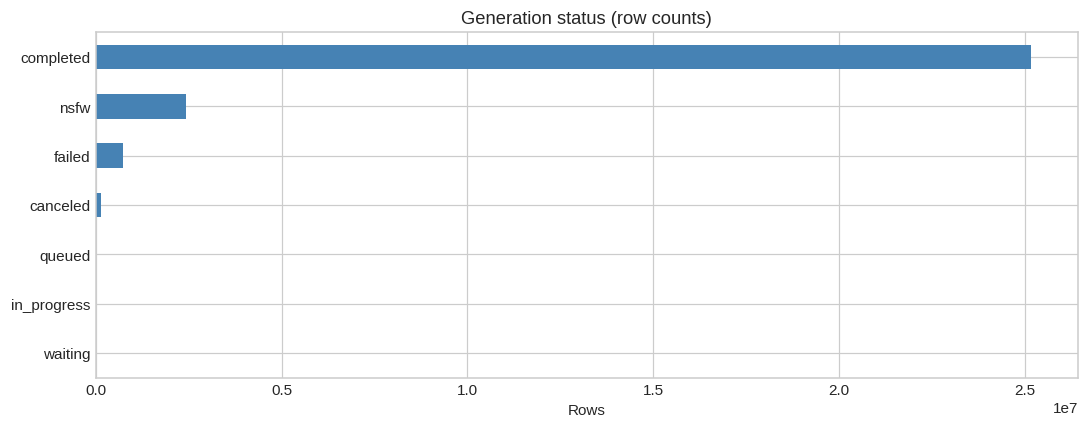

Share completed: 88.4%
Share nsfw:      8.5%


In [3]:
fig, ax = plt.subplots()
status_ser.head(8).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Rows")
ax.set_title("Generation status (row counts)")
plt.tight_layout()
plt.show()

share_completed = status_ser.get("completed", 0) / n_rows
share_nsfw = status_ser.get("nsfw", 0) / n_rows
print(f"Share completed: {share_completed:.1%}")
print(f"Share nsfw:      {share_nsfw:.1%}")

## 2. NSFW rate varies sharply by model

**Moderation hits are not uniform:** some `video_model_*` and `image_model_*` buckets show much higher `nsfw` fractions than others. That is a strong signal for both product (model risk) and user-level features (propensity toward flagged content).

*Insight:* `video_model_6` stands out with a majority of rows marked `nsfw` in the aggregate—worth treating model identity as a first-class feature, not just “image vs video.”

In [4]:
nsfw_by_type: dict[str, int] = {}
tot_by_type: dict[str, int] = {}

for ch in pd.read_csv(GEN_PATH, chunksize=CHUNK, usecols=["generation_type", "status"]):
    t = ch["generation_type"].value_counts()
    for k, v in t.items():
        tot_by_type[k] = tot_by_type.get(k, 0) + int(v)
    m = ch["status"].eq("nsfw")
    if m.any():
        g = ch.loc[m, "generation_type"].value_counts()
        for k, v in g.items():
            nsfw_by_type[k] = nsfw_by_type.get(k, 0) + int(v)

rows = []
for m, n in tot_by_type.items():
    ns = nsfw_by_type.get(m, 0)
    rows.append((m, n, ns, ns / n if n else np.nan))
nsfw_df = (
    pd.DataFrame(rows, columns=["generation_type", "n_rows", "n_nsfw", "nsfw_rate"])
    .sort_values("nsfw_rate", ascending=False)
)
display(nsfw_df.head(12))

,generation_type,n_rows,n_nsfw,nsfw_rate
15,video_model_6,334573,211970,0.633554
19,video_model_12,132022,46612,0.353062
9,image_model_8,212288,34542,0.162713
18,video_model_9,204917,31271,0.152603
2,image_model_3,1726444,250407,0.145042
11,video_model_10,197483,28114,0.142362
8,image_model_7,333698,39557,0.118541
13,video_model_5,343867,32752,0.095246
16,video_model_7,325828,28285,0.086810
1,image_model_2,2421087,205913,0.085050


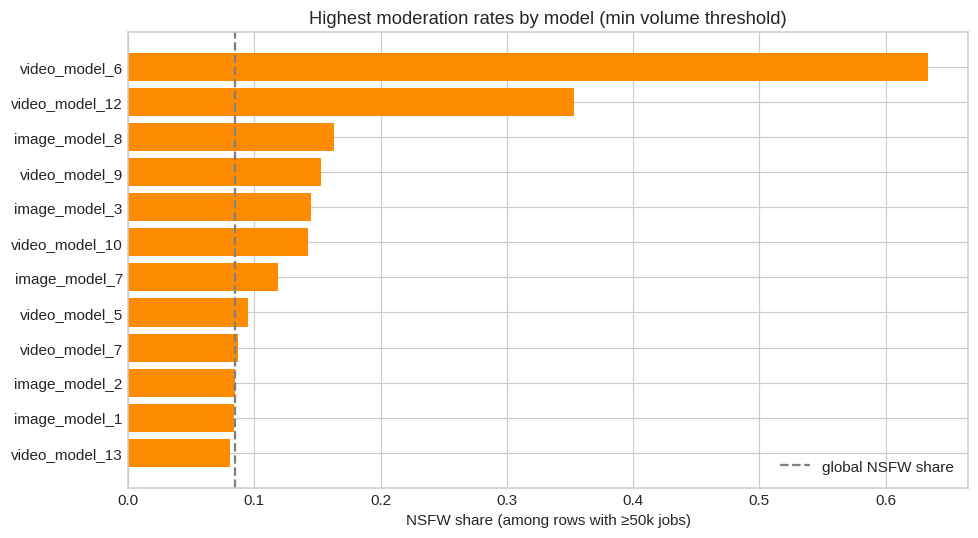

In [5]:
top = nsfw_df[nsfw_df["n_rows"] >= 50_000].sort_values("nsfw_rate", ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["generation_type"], top["nsfw_rate"], color="darkorange")
ax.set_xlabel("NSFW share (among rows with ≥50k jobs)")
ax.set_title("Highest moderation rates by model (min volume threshold)")
ax.axvline(n_rows and status_totals.get("nsfw", 0) / n_rows, color="gray", ls="--", label="global NSFW share")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Layout: aspect ratio and resolution

**Portrait vs landscape:** `9:16` is the single most common aspect ratio, then `1:1` and `16:9`—mobile-first or short-form vertical content dominates. **Resolution** is often `2k` / `1k` / `4k`; there is some duplication in labels (`720` vs `720p`) that you may want to normalize for modeling.

**Credits:** most rows have **empty `credit_cost`** in this extract—do not rely on it without imputation or a join to billing.

In [6]:
aspect_tot: dict[str, int] = {}
res_tot: dict[str, int] = {}
credit_nan = 0

for ch in pd.read_csv(GEN_PATH, chunksize=CHUNK, usecols=["aspect_ration", "resolution", "credit_cost"]):
    for k, v in ch["aspect_ration"].value_counts().items():
        aspect_tot[k] = aspect_tot.get(k, 0) + int(v)
    for k, v in ch["resolution"].value_counts().items():
        res_tot[k] = res_tot.get(k, 0) + int(v)
    credit_nan += ch["credit_cost"].isna().sum()

aspect_ser = pd.Series(aspect_tot).sort_values(ascending=False).head(10)
res_ser = pd.Series(res_tot).sort_values(ascending=False).head(8)
display(aspect_ser.to_frame("rows"))
display(res_ser.to_frame("rows"))
print("credit_cost missing:", f"{credit_nan:,}", f"({100 * credit_nan / n_rows:.1f}%)")

,rows
9:16,7170425
1:1,4693744
16:9,4316372
3:4,3138296
auto,2030431
2:3,1083976
4:5,917793
21:9,802891
4:3,590858
3:2,343067


,rows
2k,9362648
1k,4533943
4k,3366400
720p,730034
720,172487
1080,163471
1080p,145753
480p,132158


credit_cost missing: 23,837,973 (83.7%)


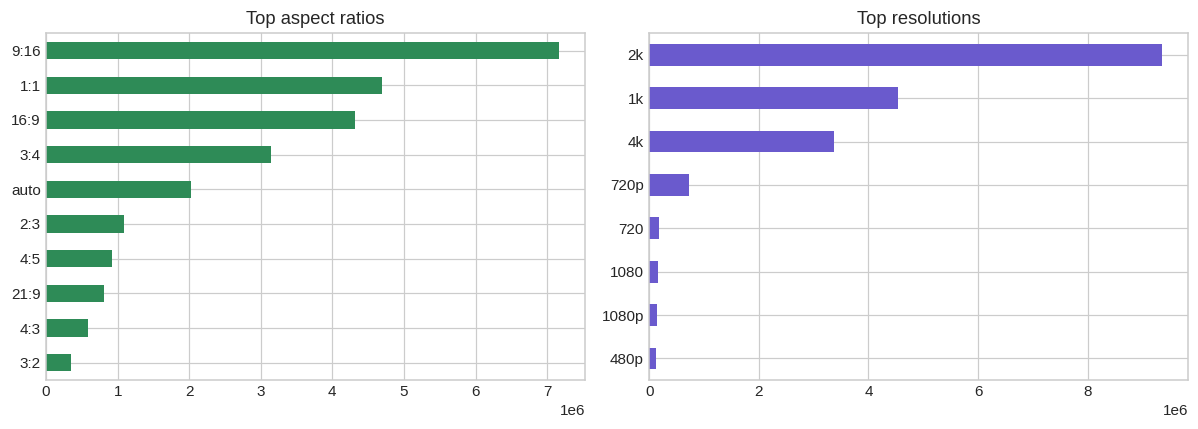

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
aspect_ser.iloc[::-1].plot(kind="barh", ax=axes[0], color="seagreen")
axes[0].set_title("Top aspect ratios")
res_ser.iloc[::-1].plot(kind="barh", ax=axes[1], color="slateblue")
axes[1].set_title("Top resolutions")
plt.tight_layout()
plt.show()

## 4. Activity vs churn

We aggregate **total generations per `user_id`** and join **`churn_status`** from `train_users.csv`. This pass scans the full generations file once (~tens of seconds on a typical machine).

**Patterns to notice:**

- **Voluntary churners** tend to have **more total generations** on average than retained users (heavy users who still leave).
- **Mean user-level NSFW rate** is higher for voluntary churn than for retained—usage intensity and moderation exposure move together in this slice.

*Caveat:* these are observational associations, not causal claims.

In [8]:
users = read_csv_drop_index(USERS_PATH)
churn = users.set_index("user_id")["churn_status"]

user_gens = Counter()
nsfw_u = Counter()

for ch in pd.read_csv(GEN_PATH, chunksize=CHUNK, usecols=["user_id", "status"]):
    for uid, v in ch["user_id"].value_counts().items():
        user_gens[uid] += int(v)
    m = ch["status"].eq("nsfw")
    if m.any():
        for uid, v in ch.loc[m, "user_id"].value_counts().items():
            nsfw_u[uid] += int(v)

counts = pd.Series(dict(user_gens), dtype="int64")
nsfw_counts = pd.Series(dict(nsfw_u)).reindex(counts.index).fillna(0).astype(int)
nsfw_rate_user = (nsfw_counts / counts).clip(upper=1.0)

idx = counts.index.intersection(churn.index)
summary = pd.DataFrame({
    "n_generations": counts.loc[idx],
    "nsfw_rate": nsfw_rate_user.loc[idx],
    "churn_status": churn.loc[idx],
})
print(summary.groupby("churn_status")["n_generations"].agg(["mean", "median", "count"]).round(1))
print()
print("Mean user-level NSFW rate by churn_status:")
print(summary.groupby("churn_status")["nsfw_rate"].mean().round(4))

               mean  median  count
churn_status                      
invol_churn   332.2   104.0  21675
not_churned   274.3    81.0  43084
vol_churn     453.3   128.0  20857

Mean user-level NSFW rate by churn_status:
churn_status
invol_churn    0.0473
not_churned    0.0338
vol_churn      0.0749
Name: nsfw_rate, dtype: float64


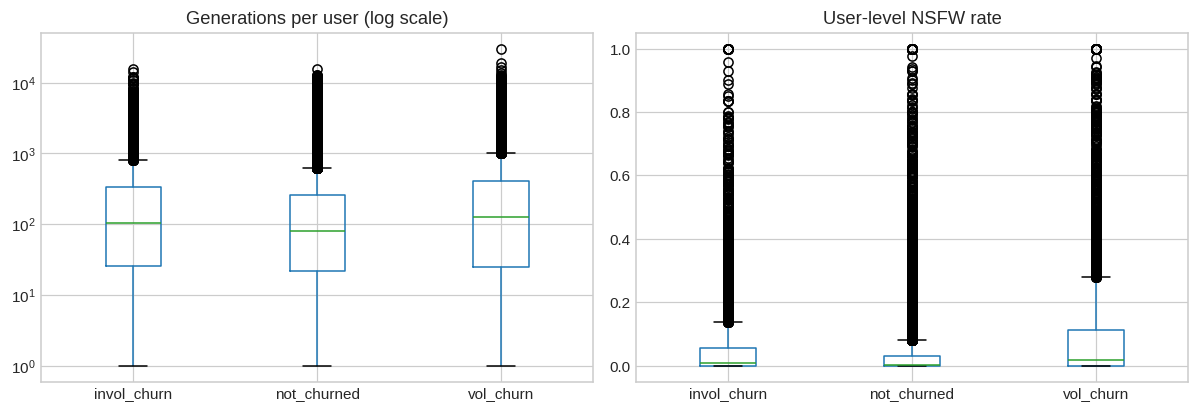

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sub = summary[summary["churn_status"].isin(["not_churned", "vol_churn", "invol_churn"])]

sub.boxplot(column="n_generations", by="churn_status", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Generations per user (log scale)")
axes[0].set_xlabel("")
plt.suptitle("")

sub.boxplot(column="nsfw_rate", by="churn_status", ax=axes[1])
axes[1].set_title("User-level NSFW rate")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 5. Video duration (spot check)

`duration` is populated mainly for video models. On a **500k-row head sample**, lengths cluster around a few seconds (median ~5s). Use a filtered read or full scan if you need production-grade duration features.

In [10]:
sample = pd.read_csv(GEN_PATH, nrows=500_000, low_memory=False)
if sample.columns[0].startswith("Unnamed"):
    sample = sample.drop(columns=sample.columns[0])
vid = sample[sample["generation_type"].str.startswith("video", na=False)]
display(vid["duration"].describe())

count    66278.000000
mean         7.312516
std          3.438468
min          1.000000
25%          5.000000
50%          5.000000
75%         10.000000
max         37.663000
Name: duration, dtype: float64

---

### Summary insights

1. **Volume:** ~28.5M jobs; **`image_model_1`** dominates volume, but **moderation risk is model-specific**—some video models show very high `nsfw` shares.
2. **Pipeline:** **`completed`** is the norm; **`nsfw`** is a distinct moderation outcome, not a generic failure.
3. **Layout:** **Vertical (`9:16`)** is the top aspect ratio; resolution clusters on **2k / 1k / 4k**.
4. **Churn linkage:** **Voluntary churn** users average **more** generations and **higher** user-level `nsfw` rates than retained users in this dataset—useful hypotheses for feature engineering (activity + risk), with the usual causal caution.
5. **Data quality:** **`credit_cost`** is mostly missing; **`aspect_ration`** is likely a typo for *ratio*; timestamp years may be **synthetic**—rely on ordering and deltas if you engineer time features.